# This cell sets up the environment and connects to the LLM.
# Run this first before anything else.

#### 2) AI generated –Personas (as in the Agile methodology)

In [8]:
import os
import sys

# Add parent directory to path so we can import utils
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Check if Pillow is installed
try:
    from PIL import Image
    print("✅ Pillow already installed")
except:
    print("Installing Pillow...")
    %pip install pillow

# Import helper functions
from utils import load_environment, get_completion

# Load API keys from .env
load_environment()

# Set up the LLM client
client = None
model_name = None
api_provider = None

try:
    from utils import setup_llm_client,clean_llm_output ,get_completion
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


Define the business_problem

In [2]:
business_problem = "Our company needs a website that generates a custom horror story and a matching image based on a location entered by the user."

#### 1) AI generated –Business problem

In [3]:
# Check if everything is ready
if client is not None and 'business_problem' in globals():
    print("Generating problem statement...")
    
    prompt = (
        "Given the business problem below, generate one clear and concise problem statement.\n"
        f"Business Problem: {business_problem}"
    )
    
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(problem_statement)
else:
    print("Skipping - client or business problem not found.")

Generating problem statement...
Develop a website where users enter a location and receive a uniquely generated horror story along with a matching AI-generated image for that location.


#### 2) AI generated –Personas (as in the Agile methodology)

In [4]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Based on the problem statement, generate exactly 3 user personas.\n"
        "For each persona, use this exact format:\n\n"
        "### Persona [N]: [Role Title]\n"
        "- **Responsibilities:** [1-2 sentences]\n"
        "- **Needs:** [1-2 specific needs related to the solution]\n\n"
        "Rules:\n"
        "- Role titles must be single words or short phrases (e.g. 'Casual User', 'Content Creator'), no slashes.\n"
        "- Responsibilities and Needs must be concrete, not abstract. Mention actual actions or features.\n"
        "- Do not add any extra text before or after the personas.\n\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.2
    )
    print(f"Personas: {personas}")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: ### Persona 1: Casual Reader
- **Responsibilities:** Enters a city or address into the website and requests a new horror story. Reviews the generated story and image, then refreshes or tries new locations.
- **Needs:** Fast story and image generation after submitting a location; a simple way to regenerate variations for the same location.

### Persona 2: Travel Blogger
- **Responsibilities:** Inputs locations from upcoming or past trips to generate themed horror content. Downloads or copies the story and image for use in blog posts and social media.
- **Needs:** Export options like copy-to-clipboard for text and image download; controls to set story length and tone (e.g., gothic, modern, folklore).

### Persona 3: Moderator
- **Responsibilities:** Reviews user-submitted locations and generated outputs for policy issues or offensive content. Flags, removes, or regenerates stories and images that violate guidelines.
- **Needs:** An admin dashboard to

#### 3) AI generated –Requirements based on the problem statement and personas

In [10]:
if client is not None and 'problem_statement' in globals() and 'personas' in globals():
    print("Generating PRD...")
    
    prompt = (
        "Write a Product Requirements Document (PRD) in markdown using only the headings listed below. "
        "Each heading must contain exactly 2-4 bullet points. "
        "Each bullet point must be one sentence and describe a specific, concrete detail. "
        "Do not write vague bullets like 'Build a good UI' — mention actual features or constraints.\n\n"
        "Start directly with '## Overview' — no introductory sentence. "
        "Do not add any headings beyond those listed. Do not write a conclusion.\n\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    prd = clean_llm_output(prd, language='markdown')
    print(prd)
    
    os.makedirs('artifacts', exist_ok=True)
    with open('artifacts/prd.md', 'w') as f:
        f.write(prd)
    print('✅Saved: artifacts/prd.md')
else:
    print("Skipping - client, problem_statement or personas missing.")

Generating PRD...
## Overview
- The website accepts a user-entered location (city, landmark, or full address) and generates a unique horror story set in that place.  
- The website generates a single AI image that visually matches the story and the submitted location context.  
- Each generation stores the location, story text, image URL, timestamp, and safety status to enable regeneration and moderation.  

## Goals
- Generate a readable horror story (default 800–1200 words) within 20 seconds after the user submits a location.  
- Generate a matching image (default 1024×1024) within 30 seconds and display it alongside the story.  
- Provide one-click actions to regenerate a variation for the same location and to try a new location without losing the previous output.  
- Enable export for creators via copy-to-clipboard for story text and direct image download as PNG.  

## Non-Goals
- The product will not provide real-time navigation, mapping, or turn-by-turn directions for the entered

#### 4) AI generated –User stories from the PRD and personas

In [11]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return a single JSON object and nothing else — no backticks, no markdown, no introductory text.\n"
        "The JSON must match this schema exactly:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n"
        "      \"role\": \"<role>\",\n      \"goal\": \"<goal>\",\n"
        "      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules:\n"
        "- Generate exactly 5 stories.\n"
        "- Each story must have exactly 2 acceptance criteria.\n"
        "- 'role', 'goal', and 'benefit' must each be no more than 20 words.\n"
        "- Each acceptance criterion must be a specific, testable action.\n"
        "- Do not add extra keys or comments.\n\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')
    print(f"User Stories: {user_stories}")
    # Save user stories as JSON
    import json, os
    os.makedirs('artifacts', exist_ok=True)
    user_stories_data = { 'user_stories': user_stories }
    with open('artifacts/user_stories.json', 'w') as f:
        json.dump(user_stories_data, f, indent=2)
    print('✅ Saved: artifacts/user_stories.json')
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Casual Reader",
      "goal": "Enter a location and generate a horror story and matching image quickly",
      "benefit": "I get an immersive experience without extra steps",
      "acceptance_criteria": [
        "When I submit a valid location and click Generate, the story text renders within 20 seconds.",
        "When generation completes, a 1024x1024 image displays next to the story within 30 seconds."
      ]
    },
    {
      "id": 2,
      "role": "Casual Reader",
      "goal": "Regenerate a new variation for the same location and settings",
      "benefit": "I can explore multiple versions without retyping",
      "acceptance_criteria": [
        "Clicking Regenerate starts a new generation using the previously normalized location, tone, and length.",
        "After regeneration finishes, the previous story and image remain accessible in the session history panel."
      ]


## Phase 2: Construction
#### 1) AI generated –UML diagrams

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor "Casual Reader" as CasualReader
actor "Travel Blogger" as TravelBlogger
actor "Moderator" as Moderator

rectangle "Horror Story Generator" {
  usecase "Generate story and image" as UC1
  usecase "Regenerate variation" as UC2
  usecase "Choose length and tone" as UC3
  usecase "Export story and image" as UC4
  usecase "Review logs and block terms" as UC5
}

CasualReader -- UC1
CasualReader -- UC2

TravelBlogger -- UC3
TravelBlogger -- UC1
TravelBlogger -- UC4

Moderator -- UC5
@enduml
✅ Saved: artifacts/diagrams/use_case_diagram.puml
✅ Diagram rendered and saved to: artifacts\artifacts\diagrams\use_case_diagram.png


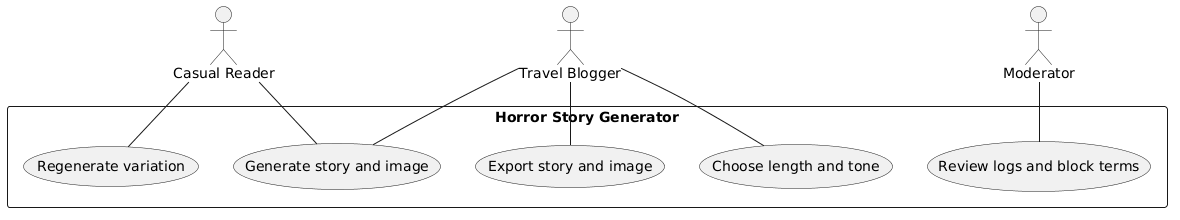

In [12]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    
    # 保证 user_stories 是字符串，避免 Python 对象直接拼接到 prompt 里
    stories_text = user_stories
    if isinstance(stories_text, (dict, list)):
        import json
        stories_text = json.dumps(stories_text, indent=2)
    
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure (placeholders like ActorName MUST be replaced with real names):\n"
        "@startuml\n"
        "actor RealActorName\n"
        "actor AnotherRealActorName\n\n"
        "rectangle \"System\" {\n"
        "  usecase \"Real Use Case Name\" as UC1\n"
        "  usecase \"Another Real Use Case\" as UC2\n"
        "}\n\n"
        "RealActorName -- UC1\n"
        "AnotherRealActorName -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary\n"
        "- The system boundary must be a `rectangle` with a meaningful system name (default: \"System\")\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead\n"
        "- Extract unique actors from the `role` field in the user stories; replace all placeholder names with these actors\n"
        "- Create one use case per distinct `goal` field; replace placeholder use case names with these goals\n"
        "- Keep use case names concise (max 5 words)\n"
        "- Only use `<<include>>` or `<<extend>>` if the user stories explicitly and unambiguously require reuse or conditional behavior. If there is any doubt, default to simple `--` associations.\n"
        "- Do NOT use any layout directives (e.g., `left to right direction`, `skinparam`). The diagram should follow default PlantUML layout.\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary\n\n"
        f"User Stories: {stories_text}"
    )

    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    if not puml.strip().startswith('@startuml') or '@enduml' not in puml:
        print("⚠️  Warning: generated PlantUML may be missing @startuml or @enduml, rendering might fail.")
    
    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")